In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import fetch_covtype


In [2]:
X, y = fetch_covtype(return_X_y=True)

In [3]:
X, _, y, _ = train_test_split(X, y, train_size=50000, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
svc = SVC(kernel='linear')

In [6]:
ova_classifier = OneVsRestClassifier(svc)
ova_classifier.fit(X_train, y_train)
y_pred_ova = ova_classifier.predict(X_test)

In [7]:
accuracy_ova = accuracy_score(y_test, y_pred_ova)
conf_matrix_ova = confusion_matrix(y_test, y_pred_ova)

In [8]:
print(f"One-vs-All Accuracy: {accuracy_ova:.4f}")
print("One-vs-All Confusion Matrix:")
print(conf_matrix_ova)

One-vs-All Accuracy: 0.7119
One-vs-All Confusion Matrix:
[[3839 1518    4    0    1    1  106]
 [1334 5768  173    0    4   12   23]
 [   0   93  809   10    2    9    0]
 [   0    0   42   20    0    9    0]
 [   2  211   24    0    1    0    7]
 [   0  155  280    0    1   13    0]
 [ 298    2    1    0    0    0  228]]


In [9]:
def plot_confusion_matrix(cm, title, ax):
    ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f'{cm[i, j]}',
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')

NameError: name 'itertools' is not defined

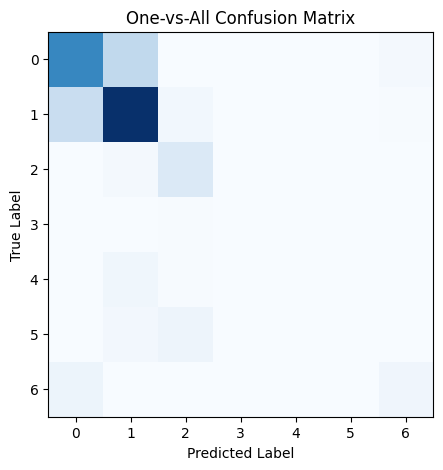

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(conf_matrix_ova, "One-vs-All Confusion Matrix", ax)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.multiclass import OneVsOneClassifier

# One-vs-One (OvO) approach
ovo_classifier = OneVsOneClassifier(svc)
ovo_classifier.fit(X_train, y_train)
y_pred_ovo = ovo_classifier.predict(X_test)

In [ ]:
accuracy_ovo = accuracy_score(y_test, y_pred_ovo)
conf_matrix_ovo = confusion_matrix(y_test, y_pred_ovo)

In [ ]:
print(f"One-vs-One Accuracy: {accuracy_ovo:.4f}")
print("One-vs-One Confusion Matrix:")
print(conf_matrix_ovo)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(conf_matrix_ovo, "One-vs-One Confusion Matrix", ax)
plt.tight_layout()
plt.show()